# Trade Execution Analysis

Every completed round-trip in a personal equity account, reconstructed from
Fidelity transaction exports covering September 2024 to August 2026.

The question is not "what did the account return" — that needs balances. It is
**how were the trades actually executed**: how often they worked, how much was
made when right against lost when wrong, how long positions were held, and
whether the losers were held longer than the winners.

Everything below is a **ratio, a percentage or a count**. No dollar amount and
no instrument is named — position sizes and holdings are not part of the
question, and an execution study does not need them.

## Loading

Fidelity caps a single export's date range, so the history arrives as several
overlapping files. Combining them is the first real problem.

The obvious approach — concatenate and drop duplicate rows — is wrong. Two
genuine fills of the same size at the same price on the same day are
indistinguishable from one row appearing in two exports, so deduplication
silently deletes real trades. It deleted three here.

Each export is a contiguous date range, so the safe unit is the **day**: where
two files cover the same date, take the rows from whichever has more for that
date and ignore the other entirely. Within a file, every row is kept.

In [1]:
import csv
import re
from collections import defaultdict, deque
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

EXPORTS = sorted(Path.home().joinpath("Downloads").glob("History_for_Account_[0-9]*.csv"))
if not EXPORTS:
    raise FileNotFoundError("No History_for_Account_*.csv in ~/Downloads")

# The export carries blank lines above the header and a disclaimer below it.
# Reverse-split lines leave Symbol empty and put the identifier in the action.
IDENTIFIER = re.compile(r"\(([A-Z0-9]{4,10})\)\s*\(")


def number(value):
    cleaned = (value or "").strip().replace("$", "").replace(",", "")
    try:
        return float(cleaned)
    except ValueError:
        return None


def read_export(path):
    lines = path.read_text(encoding="utf-8-sig", errors="replace").splitlines(keepends=True)
    start = next(i for i, line in enumerate(lines) if line.startswith("Run Date"))
    out = []
    for row in csv.DictReader(lines[start:]):
        action = (row.get("Action") or "").upper()
        side = "B" if "YOU BOUGHT" in action else "S" if "YOU SOLD" in action else None
        if side is None:
            continue
        found = IDENTIFIER.search(row.get("Action") or "")
        symbol = (row.get("Symbol") or "").strip() or (found.group(1) if found else "")
        quantity, price = number(row.get("Quantity")), number(row.get("Price ($)"))
        try:
            day = datetime.strptime((row.get("Run Date") or "").strip(), "%m/%d/%Y").date()
        except ValueError:
            continue
        if not (symbol and quantity and price):
            continue
        # Options quote per share and trade in hundreds.
        multiplier = 100 if symbol.startswith("-") else 1
        out.append(
            {"day": day, "symbol": symbol, "side": side,
             "quantity": abs(quantity), "price": price * multiplier}
        )
    return out


per_file = {path: read_export(path) for path in EXPORTS}
by_day = {
    path: {day: [r for r in rows if r["day"] == day] for day in {r["day"] for r in rows}}
    for path, rows in per_file.items()
}
merged = []
for day in sorted({d for days in by_day.values() for d in days}):
    merged.extend(max((days.get(day, []) for days in by_day.values()), key=len))
merged.sort(key=lambda r: r["day"])

naive = sum(len(rows) for rows in per_file.values())
print(f"{len(EXPORTS)} exports, {naive} rows before overlap resolution")
print(f"{len(merged)} executions kept, {merged[0]['day']} to {merged[-1]['day']}")

3 exports, 717 rows before overlap resolution
587 executions kept, 2024-09-04 to 2026-08-06


## Matching buys to sells

Fidelity does not export lot assignment, so round-trips are reconstructed
first-in-first-out. Where specific lots were sold for tax reasons the attribution
will differ from the broker's, though the totals will not.

One thing has to be counted rather than hidden. The history begins a few weeks
after the account was funded, so a handful of sells have no opening lot inside
the window. They match nothing. Dropped quietly they would flatter the result by
removing trades from the sample; they are reported instead.

In [2]:
lots = defaultdict(deque)
trips, unmatched = [], []

for row in merged:
    if row["side"] == "B":
        lots[row["symbol"]].append([row["day"], row["quantity"], row["price"]])
        continue
    remaining = row["quantity"]
    while remaining > 1e-9 and lots[row["symbol"]]:
        opened, quantity, cost = lots[row["symbol"]][0]
        taken = min(quantity, remaining)
        trips.append(
            {"opened": opened, "closed": row["day"], "held_days": (row["day"] - opened).days,
             "pnl": (row["price"] - cost) * taken,
             "pct": row["price"] / cost - 1 if cost else np.nan,
             "is_option": row["symbol"].startswith("-"), "symbol": row["symbol"]}
        )
        quantity -= taken
        remaining -= taken
        if quantity <= 1e-9:
            lots[row["symbol"]].popleft()
        else:
            lots[row["symbol"]][0][1] = quantity
    if remaining > 1e-9:
        unmatched.append(row)

trades = pd.DataFrame(trips)
still_open = sum(1 for symbol, queue in lots.items() if queue)

print(f"round-trips reconstructed : {len(trades)}")
print(f"sells with no opening lot : {len(unmatched)}  (all before {min(r['day'] for r in unmatched)
      if unmatched else 'n/a'} — opened before this history begins)")
print(f"positions still open      : {still_open}")

round-trips reconstructed : 421
sells with no opening lot : 33  (all before 2024-09-11 — opened before this history begins)
positions still open      : 14


## The core numbers

Win rate alone says very little. A strategy right 40% of the time is excellent
if the winners are three times the losers, and a strategy right 70% of the time
is a slow bleed if they are not. The pair that matters is **hit rate and payoff
ratio**, and their product is expectancy.

In [3]:
wins = trades[trades["pnl"] > 0]
losses = trades[trades["pnl"] <= 0]

hit_rate = len(wins) / len(trades)
avg_win, avg_loss = wins["pct"].mean(), losses["pct"].mean()
payoff = abs(avg_win / avg_loss)
expectancy = trades["pct"].mean()
gross_win, gross_loss = wins["pnl"].sum(), -losses["pnl"].sum()

summary = pd.DataFrame({
    "Metric": [
        "Round-trips", "Hit rate", "Average winner", "Average loser",
        "Payoff ratio", "Expectancy per trade", "Profit factor",
        "Median hold", "Longest hold",
    ],
    "Value": [
        f"{len(trades)}",
        f"{hit_rate:.1%}",
        f"{avg_win:+.2%}",
        f"{avg_loss:+.2%}",
        f"{payoff:.2f}",
        f"{expectancy:+.2%}",
        f"{gross_win / gross_loss:.2f}",
        f"{trades['held_days'].median():.0f} days",
        f"{trades['held_days'].max():.0f} days",
    ],
})
summary

,Metric,Value
0,Round-trips,421
1,Hit rate,56.5%
2,Average winner,+33.42%
3,Average loser,-15.88%
4,Payoff ratio,2.10
5,Expectancy per trade,+11.99%
6,Profit factor,2.91
7,Median hold,28 days
8,Longest hold,152 days


## Do losers get held longer?

The disposition effect — running losses and cutting gains — is the most
reliably documented mistake in retail trading. It shows up as a materially
longer median hold on losers than on winners.

The comparison below is the point of the section whichever way it falls, and a
null result is worth as much as a positive one.

In [4]:
hold = pd.DataFrame({
    "Outcome": ["Winners", "Losers"],
    "Count": [len(wins), len(losses)],
    "Median hold (days)": [wins["held_days"].median(), losses["held_days"].median()],
    "Mean hold (days)": [wins["held_days"].mean().round(1), losses["held_days"].mean().round(1)],
})
gap = losses["held_days"].median() - wins["held_days"].median()
print(f"median hold on losers minus winners: {gap:+.0f} days")
hold

median hold on losers minus winners: -1 days


,Outcome,Count,Median hold (days),Mean hold (days)
0,Winners,238,29.0,44.4
1,Losers,183,28.0,37.6


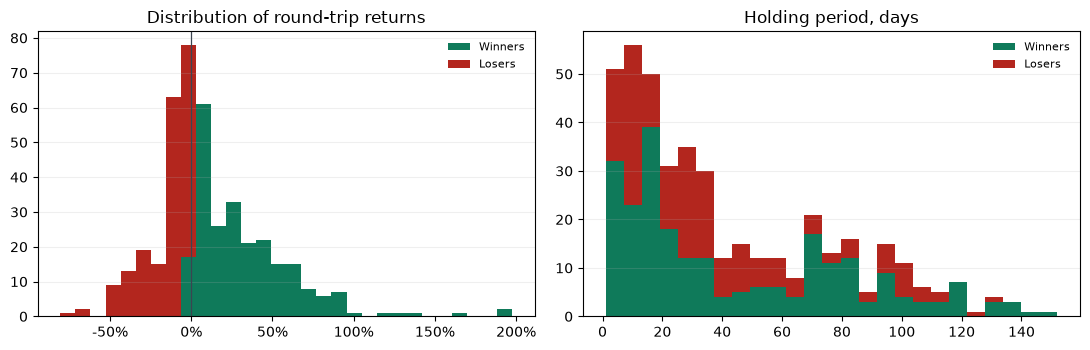

In [5]:
import matplotlib.pyplot as plt

WIN, LOSS, INK = "#0f7a5a", "#b3261e", "#3c4450"

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))

capped = trades["pct"].clip(-1, 2)
left.hist([capped[trades["pnl"] > 0], capped[trades["pnl"] <= 0]],
          bins=30, stacked=True, color=[WIN, LOSS], label=["Winners", "Losers"])
left.axvline(0, color=INK, linewidth=0.9)
left.set_title("Distribution of round-trip returns")
left.xaxis.set_major_formatter(lambda v, _p: f"{v:.0%}")
left.legend(frameon=False, fontsize=8)
left.grid(alpha=0.2, axis="y")

right.hist([wins["held_days"], losses["held_days"]], bins=25, stacked=True,
           color=[WIN, LOSS], label=["Winners", "Losers"])
right.set_title("Holding period, days")
right.legend(frameon=False, fontsize=8)
right.grid(alpha=0.2, axis="y")

plt.tight_layout()
plt.show()

## Where the profit came from

Realised profit is plotted as a share of the eventual total, so the shape is
visible without the amount. A straight line would mean profit accumulated
evenly; a staircase means a few trades did the work.

The concentration table below says the same thing numerically, without naming
anything.

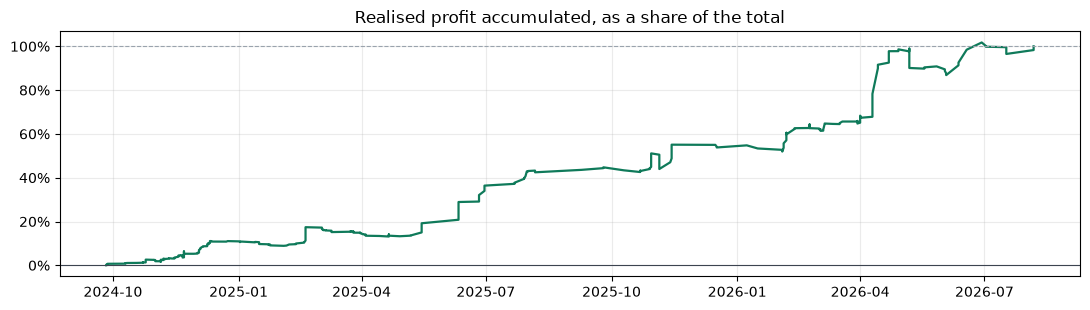

In [6]:
ordered = trades.sort_values("closed").copy()
ordered["cumulative_share"] = ordered["pnl"].cumsum() / ordered["pnl"].sum()

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(ordered["closed"], ordered["cumulative_share"], color=WIN, linewidth=1.6)
ax.axhline(0, color=INK, linewidth=0.8)
ax.axhline(1, color="#9aa3ad", linewidth=0.8, linestyle="--")
ax.set_title("Realised profit accumulated, as a share of the total")
ax.yaxis.set_major_formatter(lambda v, _p: f"{v:.0%}")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [7]:
contribution = trades.groupby("symbol")["pnl"].sum().sort_values(ascending=False)
positive = contribution[contribution > 0]
negative = contribution[contribution <= 0]

# Measured against gross gains, not net. Net profit is gains less losses, so a
# share of it exceeds 100% for any cohort large enough to cover the losers —
# arithmetically correct and unreadable as a concentration figure.
gross = positive.sum()

concentration = pd.DataFrame({
    "Cohort": ["Top 1 instrument", "Top 3", "Top 5", "Top 10", "Losing instruments"],
    "Share of gross realised gains": [
        f"{contribution.head(n).sum() / gross:.0%}" for n in (1, 3, 5, 10)
    ] + [f"{negative.sum() / gross:.0%}"],
})
print(f"{len(contribution)} instruments traded — {len(positive)} profitable, {len(negative)} not")
print(f"losses gave back {abs(negative.sum()) / gross:.0%} of gross gains")
concentration

75 instruments traded — 41 profitable, 34 not
losses gave back 24% of gross gains


,Cohort,Share of gross realised gains
0,Top 1 instrument,21%
1,Top 3,48%
2,Top 5,60%
3,Top 10,79%
4,Losing instruments,-24%


## Limits

- **FIFO is an assumption.** Fidelity exports no lot assignment. Totals are
  right; the split between individual round-trips may not match the broker's.
- **Realised only.** Open positions contribute nothing here, so this is a study
  of completed decisions, not of the account.
- **No time-weighting.** These are per-trade returns, unweighted by size or
  duration, so they describe decision quality rather than capital growth. A
  return series needs balances, which this data does not contain.
- **Survivorship of one account.** One investor, one period, one market regime.
  Nothing here generalises.